<a href="https://colab.research.google.com/github/agus-beep952/Estadisticaverano2026/blob/main/Unidad2/Gym_Member_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/agus-beep952/Estadisticaverano2026/refs/heads/main/gymmembers/gym_members_exercise_tracking.csv")

df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


+ `Edad` es del tipo entero.
+ `PP_Max`es del tipo entero.
+ `PPm_promedio` es del tipo entero.
+ `Reposo` es del tipo entero.
+ `Frecuencia_entrenamiento (days/week)` es del tipo entero.
+ `Nivel_experiencia` es del tipo entero.
+ `Genero` es del tipo categorica
+ `Tipo_entrenamiento`es del tipo categorica
+ `Peso` es del tipo numerico.
+ `Altura`es del tipo numerico.
+ `Duracionsesion_horas` es del tipo numerico.
+ `calorias_quemadas` es del tipo numerico.
+ `Porcentaje_grasa` es del tipo numerico.
+ `Consumo_agua` es del tipo numerico.
+ `IMC` es del tipo numerico.


In [61]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

In [62]:
df.rename(columns={
    "Session_Duration (hours)": "Session_Duration",
    "Weight (kg)":"Weight",
    "Height (m)":"Height",
    "Water_Intake (liters)":"Water_Intake",
    "Workout_Frequency (days/week)":"Workout_Frequency"
}, inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                973 non-null    int64  
 1   Gender             973 non-null    object 
 2   Weight             973 non-null    float64
 3   Height             973 non-null    float64
 4   Max_BPM            973 non-null    int64  
 5   Avg_BPM            973 non-null    int64  
 6   Resting_BPM        973 non-null    int64  
 7   Session_Duration   973 non-null    float64
 8   Calories_Burned    973 non-null    float64
 9   Workout_Type       973 non-null    object 
 10  Fat_Percentage     973 non-null    float64
 11  Water_Intake       973 non-null    float64
 12  Workout_Frequency  973 non-null    int64  
 13  Experience_Level   973 non-null    int64  
 14  BMI                973 non-null    float64
dtypes: float64(7), int64(6), object(2)
memory usage: 114.2+ KB


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
  Cardio     HIIT  41.2917 0.3523 -23.1974 105.7809  False
  Cardio Strength  26.1839 0.6973 -35.7784  88.1463  False
  Cardio     Yoga  18.6746 0.8721 -44.5002  81.8494  False
    HIIT Strength -15.1078 0.9306 -79.4226  49.2071  False
    HIIT     Yoga -22.6171 0.8107 -88.1009  42.8666  False
Strength     Yoga  -7.5094   0.99 -70.5062  55.4875  False
----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

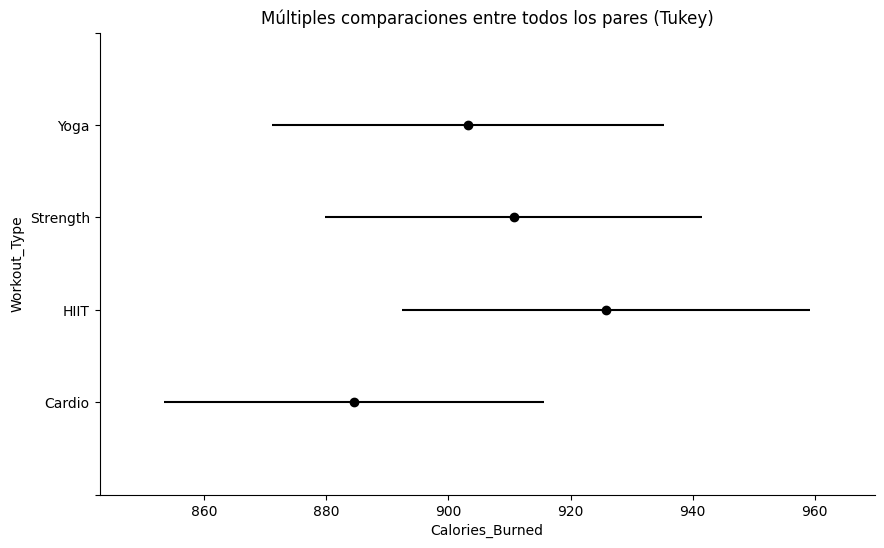

In [64]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Calories_Burned'], # Variable de respuesta
    groups=df['Workout_Type'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Workout_Type", xlabel="Calories_Burned")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

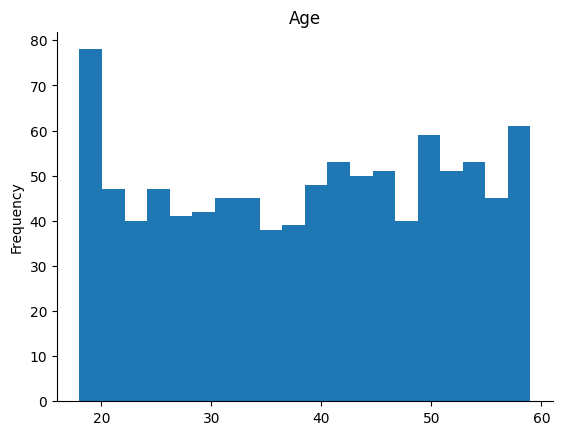

In [65]:
# @title Age

from matplotlib import pyplot as plt
df['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [66]:
df ["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [67]:
from scipy.stats import shapiro
_, valor_p_psh = shapiro(modelo_lineal.resid)
print("valor-p shapiro=", valor_p_psh)
if valor_p_psh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")

valor-p shapiro= 2.4291767943152403e-05
Los datos no siguen una distribucion normal


In [68]:
from scipy.stats import levene
grupo1 = df[df['Gender'] == 'Male']['Calories_Burned']
grupo2 = df[df['Gender'] == 'Female']['Calories_Burned']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")


p-valor de Levene: 0.0021906699819997854
Hay heterosedasticidad o Las varianzas no son iguales


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  82.2071   0.0 48.2331 116.181   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

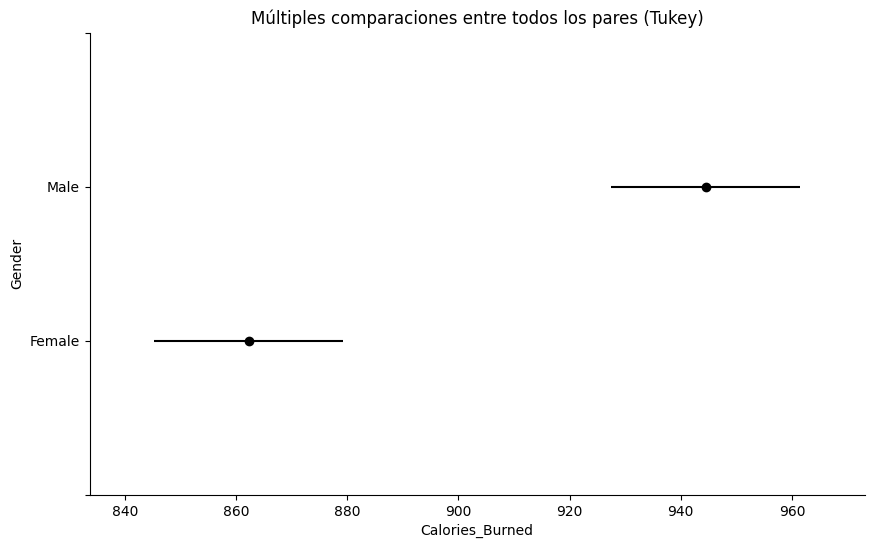

In [69]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calories_Burned'], groups=df['Gender'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Gender", xlabel="Calories_Burned")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3


In [70]:
df["Gender"]=df["Gender"].map ({"Male":1, "Female":0})
df

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [71]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols(" Calories_Burned ~ C(Workout_Type)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_psh<0.05:
  print("Ho: No hay diferencia entre X y Y")
else:
  print("H1: Si hay diferencia entre X y Y")
tabla_anova

Ho: No hay diferencia entre X y Y


,df,sum_sq,mean_sq,F,PR(>F)
C(Workout_Type),3.0,2.116701e+05,70556.703442,0.949043,0.41624
Residual,969.0,7.204039e+07,74345.089042,NaN,NaN


valor-p (Shapiro) = 2.4291767943152403e-05


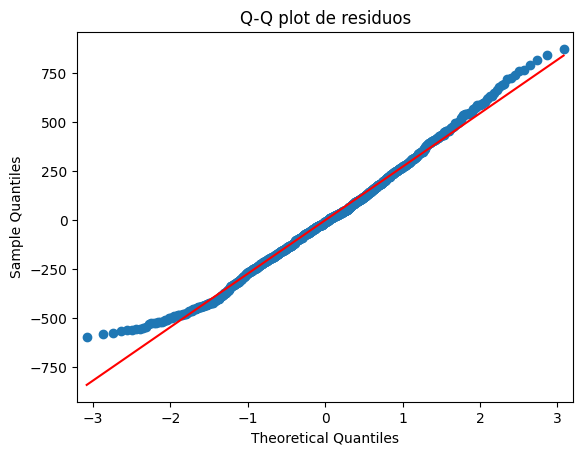

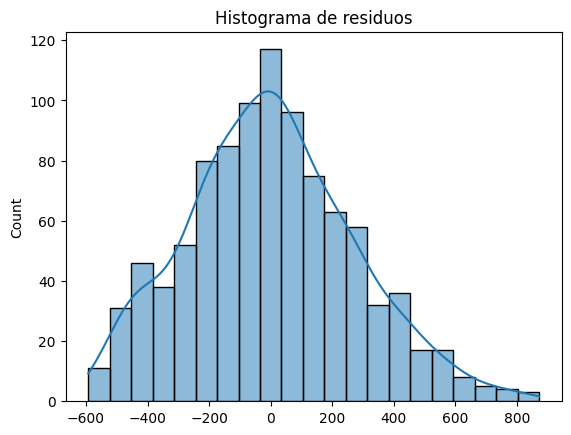

In [72]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [73]:
from scipy.stats import levene
grupo1 = df[df['Workout_Type'] == 'Yoga']['Calories_Burned']
grupo2 = df[df['Workout_Type'] == 'HIIT']['Calories_Burned']
grupo3 = df[df['Workout_Type'] == 'Cardio']['Calories_Burned']
grupo4 = df[df['Workout_Type'] == 'Strength']['Calories_Burned']



stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
if p < 0.05:
    print("Hay heterosedasticidad o Las varianzas no son iguales")
else:
    print("Hay homosedasticidad o Las varianzas son iguales")


p-valor de Levene: 0.788993613463197
Hay homosedasticidad o Las varianzas son iguales


In [75]:
df = df.drop(columns=['Workout_Type'])
df

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,Workout_Frequency,Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,3,2,37.74


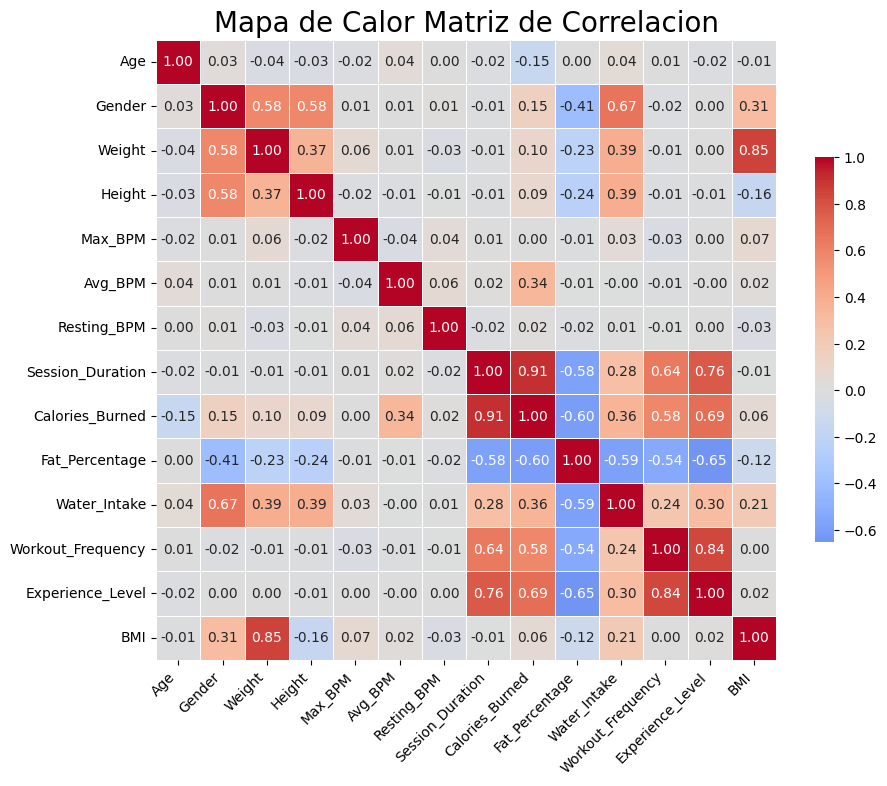

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
matriz_de_correlacion=df.corr()
plt.figure(figsize=(10,10),dpi=100)
sns.heatmap(matriz_de_correlacion, #lo que va a grafica
    annot=True,#se muestran los valores en las celdas
    fmt="0.2f", #0.2f significa 2 decimales
    cmap="coolwarm", #paleta de colroes
    square=True,#forzar cuadrado
    linewidths=0.5,#grosor de lineas
    cbar_kws={"shrink":0.5}, #tama;o de barra lateral
    center=0, #linea vertical central
)
plt.title("Mapa de Calor Matriz de Correlacion",fontsize=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Coeficiente de determinación:  0.8332

Intervalo de confianza para b1 de  95%
 663.4288 < b1 <  720.8941

valor-p de Shapiro:  0.0062

valor_p de Breusch-Pagan:  0.0000

para x1 = 0.5, x2 =3, x3=34, y = [340.55478947]
para x1 = 1.5, x2 =2, x3=50, y = [965.57265264]
para x1 = 2.5, x2 =4, x3=40, y = [1334.12409521]



,df,sum_sq,mean_sq,F,PR(>F)
Session_Duration,1.0,5.958764e+07,5.958764e+07,4792.493345,0.000000e+00
Workout_Frequency,1.0,9.606055e+03,9.606055e+03,0.772592,3.796342e-01
Fat_Percentage,1.0,6.067143e+05,6.067143e+05,48.796599,5.271702e-12
Residual,969.0,1.204810e+07,1.243354e+04,NaN,NaN


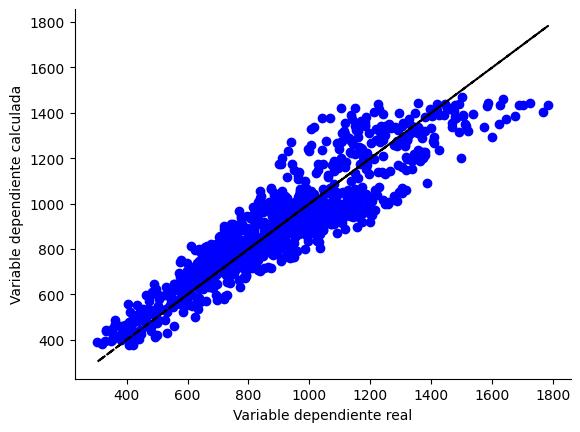

In [77]:
x = df[["Session_Duration", "Workout_Frequency", "Fat_Percentage"]]
y = df["Calories_Burned"]

# # 2. Realice un diagrama de dispersión para estos datos.
# import matplotlib.pyplot as plt
# plt.figure(figsize = (16, 8), dpi = 100)
# plt.scatter(x, y, label = "Promedio final", color = 'red')
# plt.xlabel('Exámenes cortos') # nombrar eje x
# plt.ylabel('Promedio final') # nombrar eje y
# plt.gca().spines[["top","right"]].set_visible(False)

# 3. ¿Los datos soportan la suposición de linealidad?
# Sí

# 4. Calcule el coeficiente de correlación e interprete el resultado.
# from scipy.stats import pearsonr
# r, _ = pearsonr(x, y)
# print(f'Coeficiente de correlación: {r: 0.4f}\n')

# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de
# dispersión.
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)
plt.figure()
plt.plot(y, y, color = 'black', linestyle = '--')

# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')

# 7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
# regresión ajustada ( b1 )
nivel_de_confianza = 0.95
intervalo_de_confianza = modelo.conf_int(alpha = 1 - nivel_de_confianza)
intervalo_de_confianza_b1 = intervalo_de_confianza.iloc[1]
print(f'Intervalo de confianza para b1 de {nivel_de_confianza: 0.0%}')
print(f'{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f}\n')

# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?
residuales = modelo.resid
plt.scatter(y, yc, color = 'blue')
plt.xlabel('Variable dependiente real')
plt.ylabel('Variable dependiente calculada')
plt.gca().spines[['top', 'right']].set_visible(False)

# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')

# 10. Realice la prueba de Brausch-Pagan para los residuales y comente el
# resultado.
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

# 11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de
# regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
print(f'para x1 = 0.5, x2 =3, x3=34, y = {modelo.predict([1, 0.5, 3, 34])}')
print(f'para x1 = 1.5, x2 =2, x3=50, y = {modelo.predict([1, 1.5, 2, 50])}')
print(f'para x1 = 2.5, x2 =4, x3=40, y = {modelo.predict([1, 2.0, 4, 40])}\n')
# print(f'para x = 72, y = {modelo.get_prediction([1, 0.5]).summary_frame()}')

# 12. Realice una tabla ANOVA e interprete el resultado.
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Calories_Burned ~ Session_Duration + Workout_Frequency + Fat_Percentage', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

Coeficiente de determinación:  0.9304

Intervalo de confianza para b1 de  95%
 704.4376 < b1 <  730.8560

valor-p de Shapiro:  0.0000

valor_p de Breusch-Pagan:  0.0000



,df,sum_sq,mean_sq,F,PR(>F)
Session_Duration,1.0,5.958764e+07,5.958764e+07,11501.532839,0.000000e+00
Avg_BPM,1.0,7.638999e+06,7.638999e+06,1474.470166,6.801658e-197
Residual,970.0,5.025418e+06,5.180844e+03,NaN,NaN


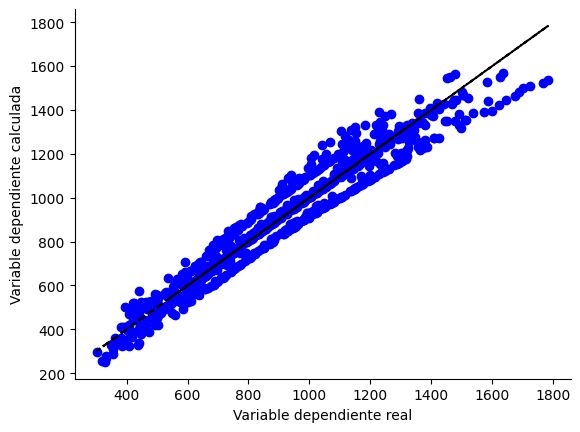

In [78]:
x = df[["Session_Duration", "Avg_BPM"]]
y = df["Calories_Burned"]

# # 2. Realice un diagrama de dispersión para estos datos.
# import matplotlib.pyplot as plt
# plt.figure(figsize = (16, 8), dpi = 100)
# plt.scatter(x, y, label = "Promedio final", color = 'red')
# plt.xlabel('Exámenes cortos') # nombrar eje x
# plt.ylabel('Promedio final') # nombrar eje y
# plt.gca().spines[["top","right"]].set_visible(False)

# 3. ¿Los datos soportan la suposición de linealidad?
# Sí

# 4. Calcule el coeficiente de correlación e interprete el resultado.
# from scipy.stats import pearsonr
# r, _ = pearsonr(x, y)
# print(f'Coeficiente de correlación: {r: 0.4f}\n')

# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de
# dispersión.
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)
plt.figure()
plt.plot(y, y, color = 'black', linestyle = '--')

# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')

# 7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
# regresión ajustada ( b1 )
nivel_de_confianza = 0.95
intervalo_de_confianza = modelo.conf_int(alpha = 1 - nivel_de_confianza)
intervalo_de_confianza_b1 = intervalo_de_confianza.iloc[1]
print(f'Intervalo de confianza para b1 de {nivel_de_confianza: 0.0%}')
print(f'{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f}\n')

# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?
residuales = modelo.resid
plt.scatter(y, yc, color = 'blue')
plt.xlabel('Variable dependiente real')
plt.ylabel('Variable dependiente calculada')
plt.gca().spines[['top', 'right']].set_visible(False)

# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')

# 10. Realice la prueba de Brausch-Pagan para los residuales y comente el
# resultado.
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

# 11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de
# regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
#print(f'para x1 = 0.5, x2 =3, x3=34, y = {modelo.predict([1, 0.5, 3, 34])}')
#print(f'para x1 = 1.5, x2 =2, x3=50, y = {modelo.predict([1, 1.5, 2, 50])}')
#print(f'para x1 = 2.5, x2 =4, x3=40, y = {modelo.predict([1, 2.0, 4, 40])}\n')
# print(f'para x = 72, y = {modelo.get_prediction([1, 0.5]).summary_frame()}')

# 12. Realice una tabla ANOVA e interprete el resultado.
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Calories_Burned ~ Session_Duration + Avg_BPM', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova